<a href="https://colab.research.google.com/github/SonicWD/deep_learning/blob/main/week7/Actividad7_Convolucion_Padding_Stride.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 7 – Convolución manual (NumPy) con **padding** y **stride**

**Curso / REA 1** · Deep learning – semana 7

**Contenido del notebook (evidencia reproducible):**
- Implementación de **convolución 2D** (correlación cruzada, estilo CNN) sin PyTorch/TensorFlow.
- Mismo **kernel 3×3** en **toda** la comparación: solo se cambia **padding** o **stride**.
- Matriz 5×5, **imagen sintética** e imagen **camera** (scikit-image), con el **mismo** kernel 3×3.
- Fórmula de **tamaño de salida** y conclusión técnica.

> En aprendizaje profundo, la “convolución” de capas `Conv2D` en realidad hace *cross-correlation* (kernel no invertido). Aquí hacemos lo mismo para alinear con la práctica estándar.

## 1. Entorno (NumPy, Matplotlib; para imagen `camera` se usa scikit-image)

In [1]:
# Primera celda: si falla "skimage" -> descomenta:
# !pip install -q numpy matplotlib scikit-image
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("ggplot")
    except OSError:
        pass
np.random.seed(7)

In [2]:
try:
    from skimage import data
    foto = data.camera().astype(np.float64) / 255.0
    print("Imagen real (camera), gris:", foto.shape)
except ImportError:
    # En Colab: descomenta !pip install scikit-image y re-ejecuta
    g = np.linspace(0, 1, 256)
    foto = np.outer(np.sin(4 * g) ** 2, np.cos(3 * g) ** 2)
    print("skimage no instalada: patrón sintético sustituto", foto.shape)

Imagen real (camera), gris: (512, 512)


## 2. Implementación manual: `convol2d` (padding + stride)

**Entrada** `X` 2D, **kernel** `K` 2D, relleno `padding` p (ceros) y `stride` s ≥ 1.

**Tamaño de salida** (válido mientras haya al menos una posición de ventana):  
H_salida = floor((H + 2p - Kh) / s) + 1; mismo criterio en el ancho. Kh, Kw: tamaño del kernel.

> Tras rellenar con ceros de forma simétrica, se desliza la ventana Kh×Kw y en cada posición se suma el producto elemento a elemento (correlación 2D, como en Keras `Conv2D`).

In [3]:
def convol2d(X: np.ndarray, K: np.ndarray, padding: int = 0, stride: int = 1) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    K = np.asarray(K, dtype=np.float64)
    if X.ndim != 2 or K.ndim != 2:
        raise ValueError("Solo 2D (una canal por implementación)")

    s = int(stride)
    p = int(padding)
    if s < 1:
        raise ValueError("stride >= 1")
    if p < 0:
        raise ValueError("padding >= 0")

    Kh, Kw = K.shape
    if Kh < 1 or Kw < 1:
        raise ValueError("Kernel vacío")

    if p > 0:
        Xp = np.pad(X, ((p, p), (p, p)), mode="constant", constant_values=0.0)
    else:
        Xp = X

    H, W = Xp.shape
    if H < Kh or W < Kw:
        raise ValueError("La entrada padeada es más pequeña que el kernel")

    out_h = (H - Kh) // s + 1
    out_w = (W - Kw) // s + 1
    if out_h < 1 or out_w < 1:
        raise ValueError("Salida no válida: revisa padding/stride vs tamaños")

    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(out_h):
        for j in range(out_w):
            si, sj = i * s, j * s
            region = Xp[si : si + Kh, sj : sj + Kw]
            out[i, j] = np.sum(region * K)
    return out

### 2.1 Prueba con matriz 5×5

In [4]:
# Mismo kernel 3×3 (Laplaciano / bordes) en todo el notebook
K_LAP = np.array(
    [
        [0.0, 1.0, 0.0],
        [1.0, -4.0, 1.0],
        [0.0, 1.0, 0.0],
    ],
    dtype=np.float64,
)
X_demo = np.array(
    [
        [1, 2, 3, 4, 5],
        [0, 1, 0, 1, 0],
        [2, 2, 2, 2, 2],
        [1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0],
    ],
    dtype=np.float64,
)
Y0 = convol2d(X_demo, K_LAP, padding=0, stride=1)
Yp = convol2d(X_demo, K_LAP, padding=1, stride=1)
print("Mismo K_LAP. Sin padding, stride 1 -> salida", Y0.shape)
print(np.round(Y0, 2))
print("Mismo K_LAP. Con padding=1, stride=1  -> salida", Yp.shape, "(bordes con más posiciones, salida mas grande)")

manual = float(np.sum(X_demo[0:3, 0:3] * K_LAP))
print("Celda [0,0] manual =", round(manual, 4), "vs convol2d[0,0] =", round(float(Y0[0, 0]), 4))

Mismo K_LAP. Sin padding, stride 1 -> salida (3, 3)
[[ 0.  7.  2.]
 [-3. -3. -3.]
 [ 4. -2.  4.]]
Mismo K_LAP. Con padding=1, stride=1  -> salida (5, 5) (bordes con más posiciones, salida mas grande)
Celda [0,0] manual = 0.0 vs convol2d[0,0] = 0.0


## 3. **Misma** imagen base, **mismo** kernel: solo cambia padding o stride

- **A — Referencia:** `padding=0`, `stride=1` (mapa de características “estándar” para 3×3).
- **B — Solo padding:** `padding=2`, `stride=1` (aumenta el tamaño de salida, mitiga pérdida en bordes al expandir con ceros).
- **C — Solo stride:** `padding=0`, `stride=2` (mismo pad que A, pero submuestreo; el mapa es más pequeño y se pierde muestreo fino).

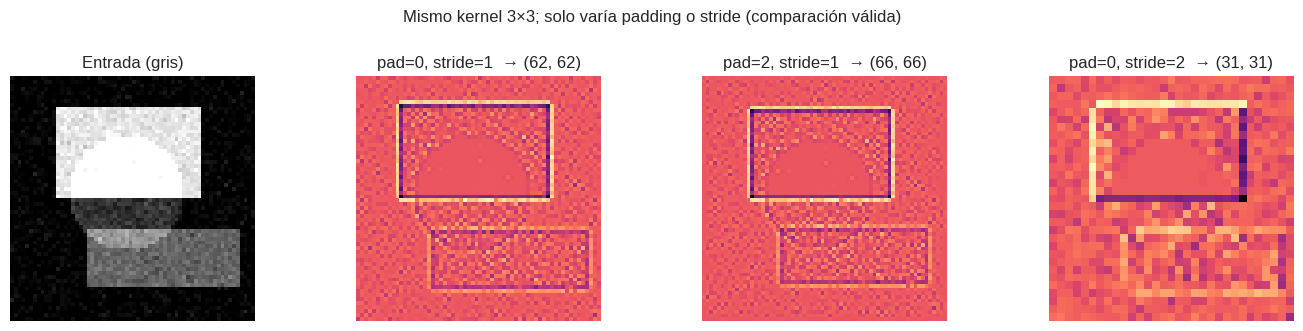

Dimensiones: entrada (64, 64)  | (A) (62, 62)  (B) (66, 66)  (C) (31, 31)


In [5]:
# Imagen sintética (evita dependencias: rectángulos, ruido)
h0, w0 = 64, 64
img = np.zeros((h0, w0), dtype=np.float64)
img[8:32, 12:50] = 0.9
img[40:55, 20:60] = 0.4
r = np.sqrt((np.arange(h0)[:, None] - 30) ** 2 + (np.arange(w0) - 30) ** 2)
img += 0.2 * (r < 15).astype(np.float64)
img = np.clip(img + 0.05 * np.random.randn(h0, w0), 0, 1)

# kernel K_LAP ya definido arriba
A = convol2d(img, K_LAP, padding=0, stride=1)
B = convol2d(img, K_LAP, padding=2, stride=1)
C = convol2d(img, K_LAP, padding=0, stride=2)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
ax = axes[0]
ax.imshow(img, cmap="gray", vmin=0, vmax=1)
ax.set_title("Entrada (gris)")
ax.axis("off")

for ax, Y, t in zip(
    axes[1:],
    [A, B, C],
    [f"pad=0, stride=1  → {A.shape}", f"pad=2, stride=1  → {B.shape}", f"pad=0, stride=2  → {C.shape}"],
):
    y = Y.copy()
    y -= y.min()
    if y.max() > 1e-8:
        y = y / y.max()
    ax.imshow(y, cmap="magma", vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis("off")
plt.suptitle("Mismo kernel 3×3; solo varía padding o stride (comparación válida)", y=1.02)
plt.tight_layout()
plt.show()

print("Dimensiones: entrada", img.shape, " | (A)", A.shape, " (B)", B.shape, " (C)", C.shape)

### 3.1 Mismo experimento con **imagen real** (camera, escala de gris)

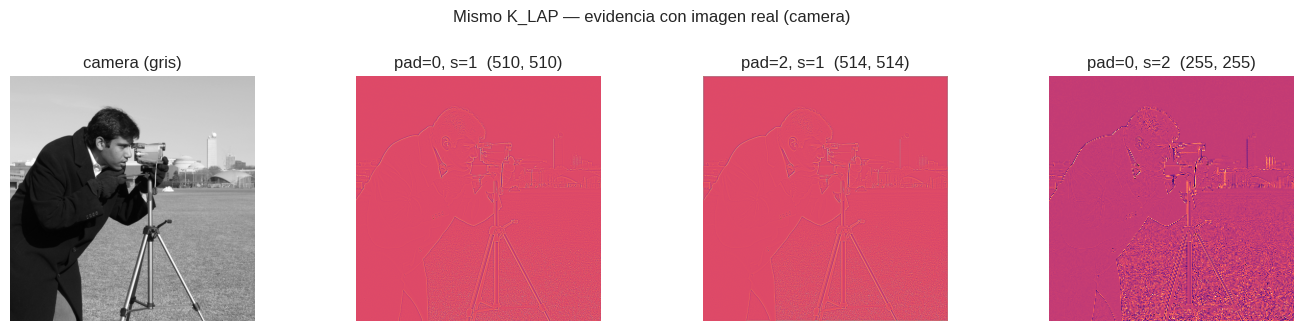

In [6]:
# Mismos híper-parámetros A, B, C; mismo K_LAP; entrada = "foto"
A2 = convol2d(foto, K_LAP, padding=0, stride=1)
B2 = convol2d(foto, K_LAP, padding=2, stride=1)
C2 = convol2d(foto, K_LAP, padding=0, stride=2)


def _norm01(Y: np.ndarray) -> np.ndarray:
    y = Y.astype(np.float64).copy()
    y -= y.min()
    m = y.max()
    if m > 1e-10:
        y /= m
    return y


fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
ax = axes[0]
ax.imshow(foto, cmap="gray", vmin=0, vmax=1)
ax.set_title("camera (gris)")
ax.axis("off")
for ax, Y, t in zip(
    axes[1:],
    [A2, B2, C2],
    [f"pad=0, s=1  {A2.shape}", f"pad=2, s=1  {B2.shape}", f"pad=0, s=2  {C2.shape}"],
):
    ax.imshow(_norm01(Y), cmap="magma", vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis("off")
plt.suptitle("Mismo K_LAP — evidencia con imagen real (camera)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Qué cambia al variar **padding** vs **stride**

- **Padding (p) con stride fijo 1:** el mapa de salida se **hace más grande** que sin pad (hasta límite fijado por p y tamaño de kernel), porque rellenar con ceros agrega región "virtual" y la ventana 3×3 alcanza más posiciones, especialmente cerca de los **bordes** de la imagen real.
- **Stride (s) con padding 0:** la ventana se mueve con pasos s; la salida es **más pequeña** (submuestreo). **No** añade información nueva: descarta puestos intermedios, útil en CNN para reducir ancho/alto, pero con pérdida de resolución espacial.
- **Mantener un solo factor** a la vez (mismo K) aísla el efecto de *borde* (padding) frente a *muestreo* (stride).

## 5. Conclusiones

A partir de la implementación manual, la comprobación en matriz pequeña y las visualizaciones con imagen sintética y en escala de gris, se extraen las siguientes conclusiones técnicas:

1. **Validez operacional:** el mapa de salida 2D se construye con la suma de productos de la región bajo el kernel, equivalente a la *cross-correlation* (modo usual de `Conv2D` en un canal), lo comprobable numéricamente en el ejemplo 5×5.  
2. **Padding (p = 2, s = 1, mismo filtro):** con respecto a *p* = 0, el mapa gana dimensiones y la influencia de los bordes de la entrada se refleja en más posiciones, al extenderse el soporte con relleno de ceros.  
3. **Stride (s = 2, p = 0, mismo filtro):** el mapa de salida reduce su resolución espacial aproximadamente a la mitad en altura y ancho, lo que ilustra el submuestreo implícito al aumentar el paso de deslizamiento, sin añadir información nueva. Los escenarios *B* (padding) y *C* (stride) se presentaron con el mismo *kernel* para separar, en la evidencia, el efecto del relleno del efecto del muestreo.